Para esta clasificación, vamos a pasar los binarios de los malware, a imagenes, para evitar riesgo de infección. Y podremos usar redes CNN

Podemos desacargar el dataset aqui: [dataset](https://drive.google.com/file/d/1M83VzyIQj_kuE9XzhClGK5TZWh1T_pr-/view)


Para este caso se subió la carpeta a Drive para poder manejar mejor los datos

In [ ]:
import os
PATH = "/content/drive/MyDrive/malimg_paper_dataset_imgs"

In [ ]:
dist = {} # Un diccionario para almacenar cuantos archivos hay en cada carpeta
for classes in os.listdir(PATH):
    paht_sub_dir = os.path.join(PATH, classes)
    dist[classes] = len(os.listdir(paht_sub_dir))

Visualizamos como están distribuidos los datos

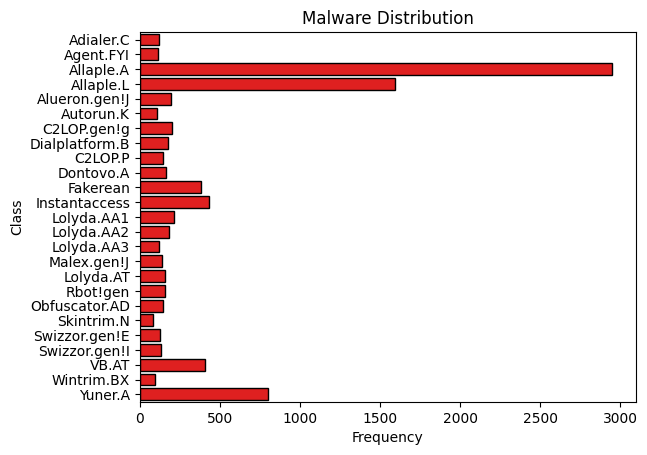

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

classes = list(dist.keys())
frequencies = list(dist.values())

# plot
sns.barplot(y=classes, x=frequencies, edgecolor = "black", orient='h', color="red")
plt.title("Malware Distribution")
plt.xlabel("Frequency")
plt.ylabel("Class")
plt.show()

#Preprocesamiento
Primero separamos los datos en 80% para entrenamiento y 20% para test

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

TARGET_PATH="./newImages"
splitfolders.ratio(input=PATH, output=TARGET_PATH, ratio=(0.8, 0, 0.2))


Copying files: 0 files [00:00, ? files/s]
Copying files: 4 files [00:00, 23.75 files/s]
Copying files: 7 files [00:00, 15.61 files/s]
Copying files: 19 files [00:00, 43.39 files/s]
Copying files: 39 files [00:00, 86.79 files/s]
Copying files: 61 files [00:00, 124.00 files/s]
Copying files: 77 files [00:00, 126.66 files/s]
Copying files: 92 files [00:00, 124.23 files/s]
Copying files: 114 files [00:01, 148.95 files/s]
Copying files: 131 files [00:01, 85.42 files/s] 
Copying files: 156 files [00:01, 114.24 files/s]
Copying files: 173 files [00:01, 124.38 files/s]
Copying files: 199 files [00:01, 153.91 files/s]
Copying files: 218 files [00:01, 155.00 files/s]
Copying files: 239 files [00:02, 73.39 files/s] 
Copying files: 255 files [00:02, 84.53 files/s]
Copying files: 270 files [00:07, 10.43 files/s]
Copying files: 270 files [00:24, 10.43 files/s]
Copying files: 271 files [00:45,  1.03 files/s]
Copying files: 272 files [01:11,  1.80s/ files]
Copying files: 285 files [01:12,  1.13s/ fil

A continuación vamos a definir un pipeline para procesamiento.
Primero definimos una transformación, para que nuestras imagenes sean de 75x75 px, pasamos la imagen a un Tensor, donde lo normalizamos. Los valores colocados son los recomendados por la comunidad.

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
	transforms.Resize((75, 75)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


Definimos a que carpetas se les aplicará la transformación. Image Folder etiqueta automáticamente cada carpeta, con categorías numéricas.

In [ ]:
from torchvision.datasets import ImageFolder

BASE_PATH = "./newImages/"

train_dataset = ImageFolder(
	root=os.path.join(BASE_PATH, "train"),
    transform=transform
)

test_dataset = ImageFolder(
	root=os.path.join(BASE_PATH, "test"),
    transform=transform
)


Finalmente creamos los conjuntos de datos que se encargarán de entrenar el modelo. De los datos escoge grupos para entrenar

In [ ]:
from torch.utils.data import DataLoader

TRAIN_BATCH_SIZE = 1024
TEST_BATCH_SIZE = 1024

train_loader = DataLoader(
    train_dataset,
	batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

Podríamos definir todo el pipeline de preprocesamiento bajo una misma función, para mayor facilidad

In [ ]:
import os
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import Image

def is_image_file(filename):
    """Checks if a file is a valid image file."""
    IMG_EXTENSIONS = [
    '.jpg', '.JPG', '.jpeg', '.JPEG',
    '.png', '.PNG', '.ppm', '.PPM', '.bmp', '.BMP',
    '.pfm', '.PFM', '.tiff', '.TIFF', '.gif', '.GIF',
    '.webp', '.WEBP',
]
    return any(filename.endswith(extension) for extension in IMG_EXTENSIONS)

def load_datasets(base_path, train_batch_size, test_batch_size):

    transform = transforms.Compose([
        transforms.Resize((75, 75)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Filter out non-image files before creating the datasets
    train_data_path = os.path.join(base_path, "train")
    test_data_path = os.path.join(base_path, "test")

    train_image_files = []
    for root, _, files in os.walk(train_data_path):
        for file in files:
            if is_image_file(file):
                train_image_files.append(os.path.join(root, file))

    test_image_files = []
    for root, _, files in os.walk(test_data_path):
        for file in files:
            if is_image_file(file):
                test_image_files.append(os.path.join(root, file))


    train_dataset = ImageFolder(
        root=train_data_path,
        transform=transform,
        is_valid_file=is_image_file # Use the helper function to validate files
    )

    test_dataset = ImageFolder(
        root=test_data_path,
        transform=transform,
         is_valid_file=is_image_file # Use the helper function to validate files

    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=2
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=2
    )

    n_classes = len(train_dataset.classes)
    return train_loader, test_loader, n_classes

# Entrenamiento
Para este ejercicio, usaremos un modelo preentrenado, además de que solo entrenaremos las capas finales, con el motivo de que el coste de entrenar un modelo nuevo y completo es muy alto, siendo la práctica para repasar conceptos.


In [ ]:
import torch.nn as nn
import torchvision.models as models

HIDDEN_LAYER_SIZE = 1000

class MalwareClassifier(nn.Module):
    def __init__(self, n_classes):
        super(MalwareClassifier, self).__init__()
        self.resnet = models.resnet50(weights='DEFAULT') #Cargamos modelo entrenado resnet50

        for param in self.resnet.parameters(): # congelamos parámetros
            param.requires_grad = False

        # remplazamo la última capa, por la nuestra, la única que se va a entrenar
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, HIDDEN_LAYER_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_LAYER_SIZE, n_classes)
        )

    def forward(self, x):
        return self.resnet(x)

Ahora que tenemos nuestro modelo, cargamos los datos preprocesados y el modelo lo cargamos con los parámetros (#clases)

In [ ]:
DATA_PATH = "./newImages/"
TRAINING_BATCH_SIZE = 1024
TEST_BATCH_SIZE = 1024

train_loader, test_loader, n_classes = load_datasets(DATA_PATH, TRAINING_BATCH_SIZE, TEST_BATCH_SIZE)

model = MalwareClassifier(n_classes)

Definimos el entrenamiento

In [ ]:
def compute_accuracy(n_correct, n_total):
    return round(100 * n_correct / n_total, 2)


In [ ]:
import torch
import time

def train(model, train_loader, n_epochs, verbose=False):
    model.train()
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters())

    training_data = {"accuracy": [], "loss": []}

    for epoch in range(n_epochs):
        running_loss = 0
        n_total = 0
        n_correct = 0
        checkpoint = time.time() * 1000

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            n_total += labels.size(0)
            n_correct += predicted.eq(labels).sum().item()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        epoch_duration = int(time.time() * 1000 - checkpoint)
        epoch_accuracy = compute_accuracy(n_correct, n_total)

        training_data["accuracy"].append(epoch_accuracy)
        training_data["loss"].append(epoch_loss)

        if verbose:
            print(f"[i] Epoch {epoch+1} of {n_epochs}: Acc: {epoch_accuracy:.2f}% Loss: {epoch_loss:.4f} (Took {epoch_duration} ms).")

    return training_data

In [ ]:
#Entrenaremos solo 8 épocas
training_information = train(model, train_loader,8 , verbose=True)

[i] Epoch 1 of 8: Acc: 82.28% Loss: 0.5452 (Took 423363 ms).
[i] Epoch 2 of 8: Acc: 88.16% Loss: 0.3256 (Took 409977 ms).
[i] Epoch 3 of 8: Acc: 90.96% Loss: 0.2607 (Took 420389 ms).
[i] Epoch 4 of 8: Acc: 92.56% Loss: 0.2133 (Took 419127 ms).
[i] Epoch 5 of 8: Acc: 93.42% Loss: 0.1888 (Took 431871 ms).
[i] Epoch 6 of 8: Acc: 94.36% Loss: 0.1615 (Took 412239 ms).
[i] Epoch 7 of 8: Acc: 95.37% Loss: 0.1451 (Took 440143 ms).
[i] Epoch 8 of 8: Acc: 96.26% Loss: 0.1298 (Took 414977 ms).


In [ ]:
def save_model(model, path):
	model_scripted = torch.jit.script(model)
	model_scripted.save(path)

In [ ]:
MODEL_FILE = "malware_classifier.pth"
save_model(model, MODEL_FILE)

In [ ]:
def predict(model, test_data):
    model.eval()

    with torch.no_grad():
        output = model(test_data)
        _, predicted = torch.max(output.data, 1)

    return predicted

def evaluate(model, test_loader):
    model.eval()

    n_correct = 0
    n_total = 0

    with torch.no_grad():
        for data, target in test_loader:
            predicted = predict(model, data)
            n_total += target.size(0)
            n_correct += (predicted == target).sum().item()

    accuracy = compute_accuracy(n_correct, n_total)

    return accuracy

In [ ]:
accuracy = evaluate(model, test_loader)

OSError: Caught OSError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/PIL/ImageFile.py", line 370, in load
    s = read(read_bytes)
        ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/PIL/PngImagePlugin.py", line 994, in load_read
    cid, pos, length = self.png.read()
                       ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/PIL/PngImagePlugin.py", line 176, in read
    length = i32(s)
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/PIL/_binary.py", line 95, in i32be
    return unpack_from(">I", c, o)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^
struct.error: unpack_from requires a buffer of at least 4 bytes for unpacking 4 bytes at offset 0 (actual buffer size is 0)

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/work